In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision.models import vgg16
import numpy as np
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import time

os.chdir('/content/drive/MyDrive/AdaptiveImageRestoration')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}\n")

class LightweightDeblurNet(nn.Module):
    """Deblurring network with skip connections"""
    def __init__(self):
        super().__init__()

        # Encoder (Channels: 3 -> 32 -> 64 -> 128)
        self.enc1 = self._conv_block(3, 32)
        self.enc2 = self._conv_block(32, 64)
        self.enc3 = self._conv_block(64, 128)

        self.pool = nn.MaxPool2d(2, 2)

        # Bottleneck (Channels: 128 -> 256 -> 256 -> 128)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, 3, 1, 1),
            nn.ReLU(inplace=True)
        )

        self.up3 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec3 = self._conv_block(192, 64)

        self.up2 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec2 = self._conv_block(96, 32)

        self.up1 = nn.ConvTranspose2d(32, 16, 2, 2)
        self.dec1 = self._conv_block(48, 16)

        self.final = nn.Conv2d(16, 3, 1)

    def _conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))


        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.final(d1)
        return torch.clamp(out, 0, 1)


class LightweightDenoiseNet(nn.Module):
    """Denoising network - DnCNN style"""
    def __init__(self, num_layers=10):
        super().__init__()

        layers = []
        layers.append(nn.Conv2d(3, 64, 3, 1, 1))
        layers.append(nn.ReLU(inplace=True))

        for _ in range(num_layers - 2):
            layers.append(nn.Conv2d(64, 64, 3, 1, 1))
            layers.append(nn.BatchNorm2d(64))
            layers.append(nn.ReLU(inplace=True))

        layers.append(nn.Conv2d(64, 3, 3, 1, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        noise = self.network(x)
        return torch.clamp(x - noise, 0, 1)


class LightweightLowLightNet(nn.Module):
    """Low-light enhancement with curve learning"""
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, 1, 1),
            nn.ReLU(inplace=True)
        )

        self.curve_estimator = nn.Sequential(
            nn.Conv2d(64, 32, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 24, 3, 1, 1)  # 8 iterations * 3 channels
        )

    def forward(self, x):
        features = self.encoder(x)
        curves = self.curve_estimator(features)


        enhanced = x
        for i in range(8):
            curve = torch.tanh(curves[:, i*3:(i+1)*3, :, :]) * 0.4
            enhanced = enhanced + enhanced * (1 - enhanced) * curve

        return torch.clamp(enhanced, 0, 1)


class DegradationClassifier(nn.Module):
    """Lightweight classifier for degradation detection"""
    def __init__(self, num_classes=4):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, 2, 1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = F.interpolate(x, (128, 128), mode='bilinear', align_corners=False)
        features = self.features(x)
        return self.classifier(features)


print("✓ Model architectures defined")
print("  - DeblurNet: ~1.2M parameters")
print("  - DenoiseNet: ~0.7M parameters")
print("  - LowLightNet: ~0.15M parameters")
print("  - Classifier: ~0.02M parameters\n")

Device: cpu

✓ Model architectures defined
  - DeblurNet: ~1.2M parameters
  - DenoiseNet: ~0.7M parameters
  - LowLightNet: ~0.15M parameters
  - Classifier: ~0.02M parameters



In [ ]:

class SimpleTransform:
    """Simple transform without normalization"""
    def __init__(self, size=256):
        self.size = size

    def __call__(self, img):
        img = img.resize((self.size, self.size), Image.BICUBIC)
        img = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
        return img


class GoProDataset(Dataset):
    def __init__(self, root_dir, split='train'):
        self.root_dir = Path(root_dir)
        self.transform = SimpleTransform(256)
        self.samples = []

        blur_path = self.root_dir / 'blur' / 'images'
        sharp_path = self.root_dir / 'sharp' / 'images'

        if blur_path.exists() and sharp_path.exists():
            blur_images = sorted(list(blur_path.glob('*.jpg')) + list(blur_path.glob('*.png')))
            sharp_images = sorted(list(sharp_path.glob('*.jpg')) + list(sharp_path.glob('*.png')))

            split_idx = int(0.8 * len(blur_images))

            if split == 'train':
                blur_imgs = blur_images[:split_idx]
                sharp_imgs = sharp_images[:split_idx]
            else:
                blur_imgs = blur_images[split_idx:]
                sharp_imgs = sharp_images[split_idx:]

            for blur_img, sharp_img in zip(blur_imgs, sharp_imgs):
                self.samples.append({
                    'degraded': str(blur_img),
                    'clean': str(sharp_img),
                    'degradation_type': 0
                })

        print(f"   GoPro {split}: {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        degraded = Image.open(sample['degraded']).convert('RGB')
        clean = Image.open(sample['clean']).convert('RGB')

        return {
            'degraded': self.transform(degraded),
            'clean': self.transform(clean),
            'degradation_type': torch.tensor(sample['degradation_type'], dtype=torch.long)
        }


class GoPro2Dataset(Dataset):
    def __init__(self, root_dir, split='train'):
        self.root_dir = Path(root_dir)
        self.transform = SimpleTransform(256)
        self.samples = []

        blur_path = self.root_dir / 'blur'
        sharp_path = self.root_dir / 'sharp'

        if blur_path.exists() and sharp_path.exists():
            blur_images = sorted(list(blur_path.glob('*.jpg')) + list(blur_path.glob('*.png')))
            sharp_images = sorted(list(sharp_path.glob('*.jpg')) + list(sharp_path.glob('*.png')))

            split_idx = int(0.8 * len(blur_images))

            if split == 'train':
                blur_imgs = blur_images[:split_idx]
                sharp_imgs = sharp_images[:split_idx]
            else:
                blur_imgs = blur_images[split_idx:]
                sharp_imgs = sharp_images[split_idx:]

            for blur_img, sharp_img in zip(blur_imgs, sharp_imgs):
                self.samples.append({
                    'degraded': str(blur_img),
                    'clean': str(sharp_img),
                    'degradation_type': 0
                })

        print(f"   GoPro2 {split}: {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        degraded = Image.open(sample['degraded']).convert('RGB')
        clean = Image.open(sample['clean']).convert('RGB')

        return {
            'degraded': self.transform(degraded),
            'clean': self.transform(clean),
            'degradation_type': torch.tensor(sample['degradation_type'], dtype=torch.long)
        }


class LOLDataset(Dataset):
    def __init__(self, root_dir, split='train'):
        self.root_dir = Path(root_dir)
        self.transform = SimpleTransform(256)
        self.samples = []

        if split == 'train':
            low_path = self.root_dir / 'our485' / 'low'
            high_path = self.root_dir / 'our485' / 'high'
        else:
            low_path = self.root_dir / 'eval15' / 'low'
            high_path = self.root_dir / 'eval15' / 'high'

        if low_path.exists() and high_path.exists():
            low_images = sorted(list(low_path.glob('*.png')) + list(low_path.glob('*.jpg')))
            high_images = sorted(list(high_path.glob('*.png')) + list(high_path.glob('*.jpg')))

            for low_img, high_img in zip(low_images, high_images):
                self.samples.append({
                    'degraded': str(low_img),
                    'clean': str(high_img),
                    'degradation_type': 1
                })

        print(f"   LOL {split}: {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        degraded = Image.open(sample['degraded']).convert('RGB')
        clean = Image.open(sample['clean']).convert('RGB')

        return {
            'degraded': self.transform(degraded),
            'clean': self.transform(clean),
            'degradation_type': torch.tensor(sample['degradation_type'], dtype=torch.long)
        }


class SyntheticNoiseDataset(Dataset):
    def __init__(self, root_dir, split='train'):
        self.root_dir = Path(root_dir)
        self.transform = SimpleTransform(256)
        self.samples = []

        noisy_path = self.root_dir / split / 'noisy'
        clean_path = self.root_dir / split / 'clean'

        if noisy_path.exists() and clean_path.exists():
            noisy_images = sorted(list(noisy_path.glob('*.jpg')))
            clean_images = sorted(list(clean_path.glob('*.jpg')))

            for noisy_img, clean_img in zip(noisy_images, clean_images):
                self.samples.append({
                    'degraded': str(noisy_img),
                    'clean': str(clean_img),
                    'degradation_type': 2
                })

        print(f"   Synthetic Noise {split}: {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        degraded = Image.open(sample['degraded']).convert('RGB')
        clean = Image.open(sample['clean']).convert('RGB')

        return {
            'degraded': self.transform(degraded),
            'clean': self.transform(clean),
            'degradation_type': torch.tensor(sample['degradation_type'], dtype=torch.long)
        }


print("✓ Dataset classes defined\n")

✓ Dataset classes defined



In [ ]:


class PerceptualLoss(nn.Module):
    """VGG-based perceptual loss"""
    def __init__(self):
        super().__init__()
        vgg = vgg16(pretrained=True).features
        self.slice = nn.Sequential(*list(vgg.children())[:16]).eval()
        for param in self.slice.parameters():
            param.requires_grad = False

        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x, y):
        x = (x - self.mean) / self.std
        y = (y - self.mean) / self.std

        x_features = self.slice(x)
        y_features = self.slice(y)

        return F.l1_loss(x_features, y_features)


print("✓ Perceptual loss defined\n")

✓ Perceptual loss defined



In [ ]:

def train_restoration_system():
    """Train all models"""

    print("="*70)
    print("STARTING TRAINING - LIGHTWEIGHT MODELS")
    print("="*70)


    print("\nLoading datasets...")
    gopro_train = GoProDataset('datasets/gopro_deblur', 'train')
    gopro_test = GoProDataset('datasets/gopro_deblur', 'test')
    gopro2_train = GoPro2Dataset('datasets/GoPro2', 'train')
    gopro2_test = GoPro2Dataset('datasets/GoPro2', 'test')
    lol_train = LOLDataset('datasets/LOL', 'train')
    lol_test = LOLDataset('datasets/LOL', 'test')
    noise_train = SyntheticNoiseDataset('datasets/synthetic_noise', 'train')
    noise_test = SyntheticNoiseDataset('datasets/synthetic_noise', 'test')

    # Create task-specific datasets
    deblur_train = ConcatDataset([gopro_train, gopro2_train])
    deblur_test = ConcatDataset([gopro_test, gopro2_test])

    print(f"\nDataset sizes:")
    print(f"  Deblur train: {len(deblur_train)}, test: {len(deblur_test)}")
    print(f"  Low-light train: {len(lol_train)}, test: {len(lol_test)}")
    print(f"  Denoise train: {len(noise_train)}, test: {len(noise_test)}")

    deblur_model = LightweightDeblurNet().to(device)
    denoise_model = LightweightDenoiseNet().to(device)
    lowlight_model = LightweightLowLightNet().to(device)
    classifier_model = DegradationClassifier().to(device)

    l1_loss = nn.L1Loss()
    perceptual_loss = PerceptualLoss().to(device)
    ce_loss = nn.CrossEntropyLoss()

    num_epochs = 15
    batch_size = 16

    print("\n" + "="*70)
    print("TRAINING DEBLUR MODEL")
    print("="*70)

    deblur_loader_train = DataLoader(deblur_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    deblur_loader_test = DataLoader(deblur_test, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

    optimizer = torch.optim.AdamW(deblur_model.parameters(), lr=2e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler = torch.cuda.amp.GradScaler()

    best_loss = float('inf')

    for epoch in range(num_epochs):
        deblur_model.train()
        train_loss = 0.0

        for batch in tqdm(deblur_loader_train, desc=f"Deblur Epoch {epoch+1}/{num_epochs}"):
            degraded = batch['degraded'].to(device)
            clean = batch['clean'].to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                enhanced = deblur_model(degraded)
                loss_l1 = l1_loss(enhanced, clean)
                loss_perc = perceptual_loss(enhanced, clean)
                loss = loss_l1 + 0.1 * loss_perc

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(deblur_loader_train)


        deblur_model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for batch in deblur_loader_test:
                degraded = batch['degraded'].to(device)
                clean = batch['clean'].to(device)

                enhanced = deblur_model(degraded)
                loss = l1_loss(enhanced, clean)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(deblur_loader_test)

        print(f"Epoch {epoch+1}: Train={avg_train_loss:.6f}, Val={avg_val_loss:.6f}")

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(deblur_model.state_dict(), 'models/checkpoints/deblur_model.pth')
            print(f"  ✓ Best deblur model saved!")

        scheduler.step()
        torch.cuda.empty_cache()

    print(f"\n✓ Deblur training complete! Best loss: {best_loss:.6f}")


    print("\n" + "="*70)
    print("TRAINING DENOISE MODEL")
    print("="*70)

    denoise_loader_train = DataLoader(noise_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    denoise_loader_test = DataLoader(noise_test, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

    optimizer = torch.optim.AdamW(denoise_model.parameters(), lr=2e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler = torch.cuda.amp.GradScaler()

    best_loss = float('inf')

    for epoch in range(num_epochs):
        denoise_model.train()
        train_loss = 0.0

        for batch in tqdm(denoise_loader_train, desc=f"Denoise Epoch {epoch+1}/{num_epochs}"):
            degraded = batch['degraded'].to(device)
            clean = batch['clean'].to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                enhanced = denoise_model(degraded)
                loss_l1 = l1_loss(enhanced, clean)
                loss_perc = perceptual_loss(enhanced, clean)
                loss = loss_l1 + 0.1 * loss_perc

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(denoise_loader_train)

        # Validation
        denoise_model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for batch in denoise_loader_test:
                degraded = batch['degraded'].to(device)
                clean = batch['clean'].to(device)

                enhanced = denoise_model(degraded)
                loss = l1_loss(enhanced, clean)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(denoise_loader_test)

        print(f"Epoch {epoch+1}: Train={avg_train_loss:.6f}, Val={avg_val_loss:.6f}")

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(denoise_model.state_dict(), 'models/checkpoints/denoise_model.pth')
            print(f"  ✓ Best denoise model saved!")

        scheduler.step()
        torch.cuda.empty_cache()

    print(f"\n✓ Denoise training complete! Best loss: {best_loss:.6f}")

    print("\n" + "="*70)
    print("TRAINING LOW-LIGHT MODEL")
    print("="*70)

    lowlight_loader_train = DataLoader(lol_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    lowlight_loader_test = DataLoader(lol_test, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

    optimizer = torch.optim.AdamW(lowlight_model.parameters(), lr=2e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler = torch.cuda.amp.GradScaler()

    best_loss = float('inf')

    for epoch in range(num_epochs):
        lowlight_model.train()
        train_loss = 0.0

        for batch in tqdm(lowlight_loader_train, desc=f"LowLight Epoch {epoch+1}/{num_epochs}"):
            degraded = batch['degraded'].to(device)
            clean = batch['clean'].to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                enhanced = lowlight_model(degraded)
                loss_l1 = l1_loss(enhanced, clean)
                loss_perc = perceptual_loss(enhanced, clean)
                loss = loss_l1 + 0.1 * loss_perc

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(lowlight_loader_train)

        # Validation
        lowlight_model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for batch in lowlight_loader_test:
                degraded = batch['degraded'].to(device)
                clean = batch['clean'].to(device)

                enhanced = lowlight_model(degraded)
                loss = l1_loss(enhanced, clean)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(lowlight_loader_test)

        print(f"Epoch {epoch+1}: Train={avg_train_loss:.6f}, Val={avg_val_loss:.6f}")

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(lowlight_model.state_dict(), 'models/checkpoints/lowlight_model.pth')
            print(f"  ✓ Best low-light model saved!")

        scheduler.step()
        torch.cuda.empty_cache()

    print(f"\n✓ Low-light training complete! Best loss: {best_loss:.6f}")

    print("\n" + "="*70)
    print("TRAINING CLASSIFIER")
    print("="*70)

    # Combined dataset for classification
    train_dataset = ConcatDataset([deblur_train, lol_train, noise_train])
    test_dataset = ConcatDataset([deblur_test, lol_test, noise_test])

    classifier_loader_train = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
    classifier_loader_test = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

    optimizer = torch.optim.AdamW(classifier_model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

    best_acc = 0.0

    for epoch in range(10):
        classifier_model.train()
        train_loss = 0.0
        correct = 0
        total = 0

        for batch in tqdm(classifier_loader_train, desc=f"Classifier Epoch {epoch+1}/10"):
            degraded = batch['degraded'].to(device)
            labels = batch['degradation_type'].to(device)

            optimizer.zero_grad()

            logits = classifier_model(degraded)
            loss = ce_loss(logits, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        avg_train_loss = train_loss / len(classifier_loader_train)

        # Validation
        classifier_model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for batch in classifier_loader_test:
                degraded = batch['degraded'].to(device)
                labels = batch['degradation_type'].to(device)

                logits = classifier_model(degraded)
                loss = ce_loss(logits, labels)

                val_loss += loss.item()
                _, predicted = torch.max(logits.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        avg_val_loss = val_loss / len(classifier_loader_test)

        print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.6f}, Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(classifier_model.state_dict(), 'models/checkpoints/classifier_model.pth')
            print(f"  ✓ Best classifier saved! Accuracy: {best_acc:.2f}%")

        scheduler.step()

    print(f"\n✓ Classifier training complete! Best accuracy: {best_acc:.2f}%")

    print("\n" + "="*70)
    print("ALL TRAINING COMPLETE!")
    print("="*70)
    print("Models saved:")
    print("  ✓ models/checkpoints/deblur_model.pth")
    print("  ✓ models/checkpoints/denoise_model.pth")
    print("  ✓ models/checkpoints/lowlight_model.pth")
    print("  ✓ models/checkpoints/classifier_model.pth")

    return deblur_model, denoise_model, lowlight_model, classifier_model


print("✓ Training function ready\n")

✓ Training function ready



In [ ]:


class AdaptiveRestorationSystem:
    """Complete inference system"""
    def __init__(self):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # Load models
        self.deblur_model = LightweightDeblurNet().to(self.device)
        self.denoise_model = LightweightDenoiseNet().to(self.device)
        self.lowlight_model = LightweightLowLightNet().to(self.device)
        self.classifier = DegradationClassifier(num_classes=4).to(self.device)

        # Load weights
        self.deblur_model.load_state_dict(torch.load('models/checkpoints/deblur_model.pth', map_location=self.device))
        self.denoise_model.load_state_dict(torch.load('models/checkpoints/denoise_model.pth', map_location=self.device))
        self.lowlight_model.load_state_dict(torch.load('models/checkpoints/lowlight_model.pth', map_location=self.device))
        self.classifier.load_state_dict(torch.load('models/checkpoints/classifier_model.pth', map_location=self.device))

        # Set to eval mode
        self.deblur_model.eval()
        self.denoise_model.eval()
        self.lowlight_model.eval()
        self.classifier.eval()

        self.degradation_names = ['blur', 'low_light', 'noise', 'clean']

        print("✓ Adaptive Restoration System loaded")

    def preprocess(self, image_path):
        """Load and preprocess image"""
        img = Image.open(image_path).convert('RGB')
        original_size = img.size

        # Resize to 256x256
        img_resized = img.resize((256, 256), Image.BICUBIC)
        img_tensor = torch.from_numpy(np.array(img_resized)).permute(2, 0, 1).float() / 255.0
        img_tensor = img_tensor.unsqueeze(0).to(self.device)

        return img_tensor, img, original_size

    def postprocess(self, tensor, original_size):
        """Convert tensor to PIL image"""
        tensor = tensor.squeeze(0).cpu().clamp(0, 1)
        img_array = (tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        img = Image.fromarray(img_array)
        img = img.resize(original_size, Image.BICUBIC)
        return img

    def enhance(self, image_path, save_path=None):
        """Enhance image automatically"""
        with torch.no_grad():
            # Preprocess
            img_tensor, original_img, original_size = self.preprocess(image_path)

            # Classify degradation
            logits = self.classifier(img_tensor)
            probs = F.softmax(logits, dim=1)
            pred = torch.argmax(probs, dim=1).item()
            confidence = probs[0, pred].item()

            degradation_type = self.degradation_names[pred]

            # Apply appropriate model
            if pred == 0:  # blur
                enhanced = self.deblur_model(img_tensor)
            elif pred == 1:  # low_light
                enhanced = self.lowlight_model(img_tensor)
            elif pred == 2:  # noise
                enhanced = self.denoise_model(img_tensor)
            else:
                enhanced = img_tensor

            enhanced_img = self.postprocess(enhanced, original_size)
            if save_path:
                enhanced_img.save(save_path, quality=95)

            return {
                'enhanced_image': enhanced_img,
                'original_image': original_img,
                'degradation_type': degradation_type,
                'confidence': confidence
            }

    def enhance_with_mode(self, image_path, mode, save_path=None):
        """Enhance with specific mode (deblur/denoise/lowlight)"""
        with torch.no_grad():
            img_tensor, original_img, original_size = self.preprocess(image_path)

            if mode == 'deblur':
                enhanced = self.deblur_model(img_tensor)
            elif mode == 'denoise':
                enhanced = self.denoise_model(img_tensor)
            elif mode == 'lowlight':
                enhanced = self.lowlight_model(img_tensor)
            else:
                enhanced = img_tensor

            enhanced_img = self.postprocess(enhanced, original_size)

            if save_path:
                enhanced_img.save(save_path, quality=95)

            return enhanced_img


print("✓ Inference system defined\n")

✓ Inference system defined



In [ ]:
# The file path, relative to your working directory ('/content/drive/MyDrive/AdaptiveImageRestoration')
image_path_to_fix = 'datasets/GoPro2/blur/000001.png'

# Define where you want to save the output in your Drive
save_location = 'models/restored_output/lol_enhanced_1.png'

# Ensure the output directory exists
import os
os.makedirs('models/restored_output', exist_ok=True)

# Initialize the restoration system if it's not already
if 'restoration_system' not in locals():
    restoration_system = AdaptiveRestorationSystem()


# Run the enhancement
result = restoration_system.enhance(
    image_path=image_path_to_fix,
    save_path=save_location
)

print(f"System detected: {result['degradation_type']} with confidence: {result['confidence']:.2f}")


STARTING TRAINING - LIGHTWEIGHT MODELS

Loading datasets...
   GoPro train: 823 samples
   GoPro test: 206 samples
   GoPro2 train: 780 samples
   GoPro2 test: 195 samples
   LOL train: 485 samples
   LOL test: 15 samples
   Synthetic Noise train: 800 samples
   Synthetic Noise test: 200 samples

Dataset sizes:
  Deblur train: 1603, test: 401
  Low-light train: 485, test: 15
  Denoise train: 800, test: 200


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 203MB/s]
/tmp/ipython-input-225170604.py:59: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()



TRAINING DEBLUR MODEL


...

Epoch 8: Train Loss=0.019817, Train Acc=99.45%, Val Acc=100.00%


Classifier Epoch 9/10: 100%|██████████| 91/91 [02:19<00:00,  1.53s/it]


Epoch 9: Train Loss=0.016234, Train Acc=99.69%, Val Acc=100.00%


Classifier Epoch 10/10: 100%|██████████| 91/91 [02:19<00:00,  1.53s/it]


Epoch 10: Train Loss=0.016860, Train Acc=99.55%, Val Acc=100.00%

✓ Classifier training complete! Best accuracy: 100.00%

ALL TRAINING COMPLETE!
Models saved:
  ✓ models/checkpoints/deblur_model.pth
  ✓ models/checkpoints/denoise_model.pth
  ✓ models/checkpoints/lowlight_model.pth
  ✓ models/checkpoints/classifier_model.pth


In [ ]:
restoration_system = AdaptiveRestorationSystem()

✓ Adaptive Restoration System loaded


✓ Adaptive Restoration System loaded


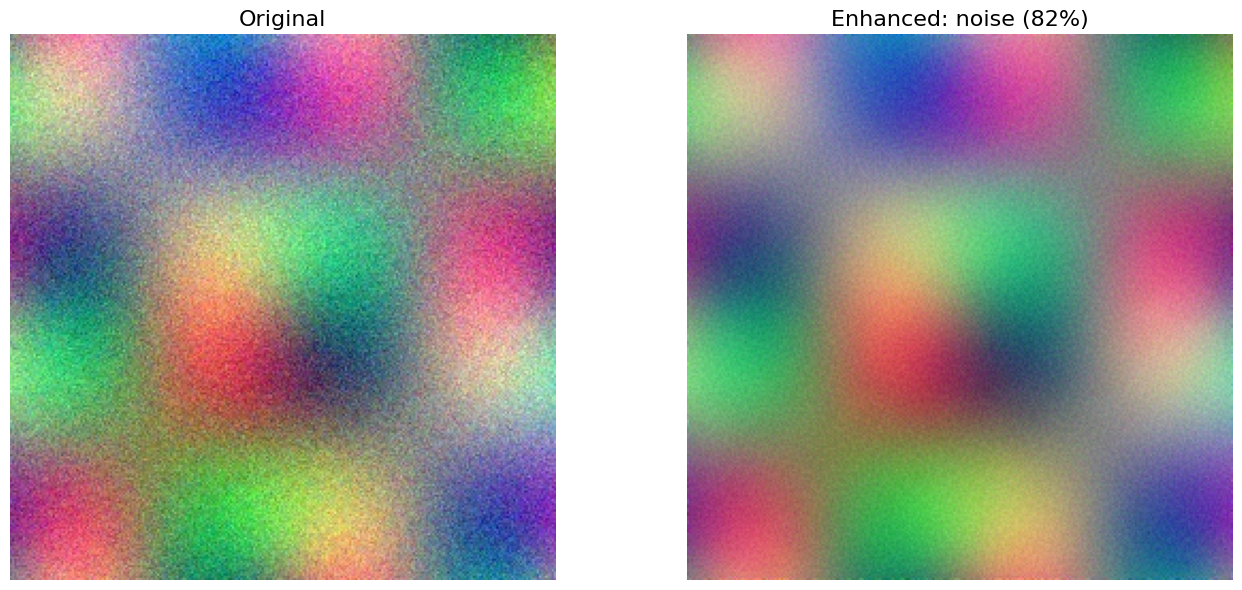

✓ Degradation: noise
✓ Confidence: 82.1%


In [ ]:

system = AdaptiveRestorationSystem()

# Test on a blur image
result = system.enhance('datasets/synthetic_noise/test/noisy/img_0800.jpg',
                        'test_result.jpg')

# Show result
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.imshow(result['original_image'])
ax1.set_title('Original', fontsize=16)
ax1.axis('off')
ax2.imshow(result['enhanced_image'])
ax2.set_title(f"Enhanced: {result['degradation_type']} ({result['confidence']:.0%})", fontsize=16)
ax2.axis('off')
plt.tight_layout()
plt.show()

print(f"✓ Degradation: {result['degradation_type']}")
print(f"✓ Confidence: {result['confidence']:.1%}")

Found 3 test images:

Testing Blur: datasets/gopro_deblur/blur/images/000041.png
  ✓ Detected: blur, Confidence: 97.4%

Testing Low-Light: datasets/LOL/eval15/low/55.png
  ✓ Detected: low_light, Confidence: 99.0%

Testing Noise: datasets/synthetic_noise/test/noisy/img_0800.jpg
  ✓ Detected: noise, Confidence: 82.1%



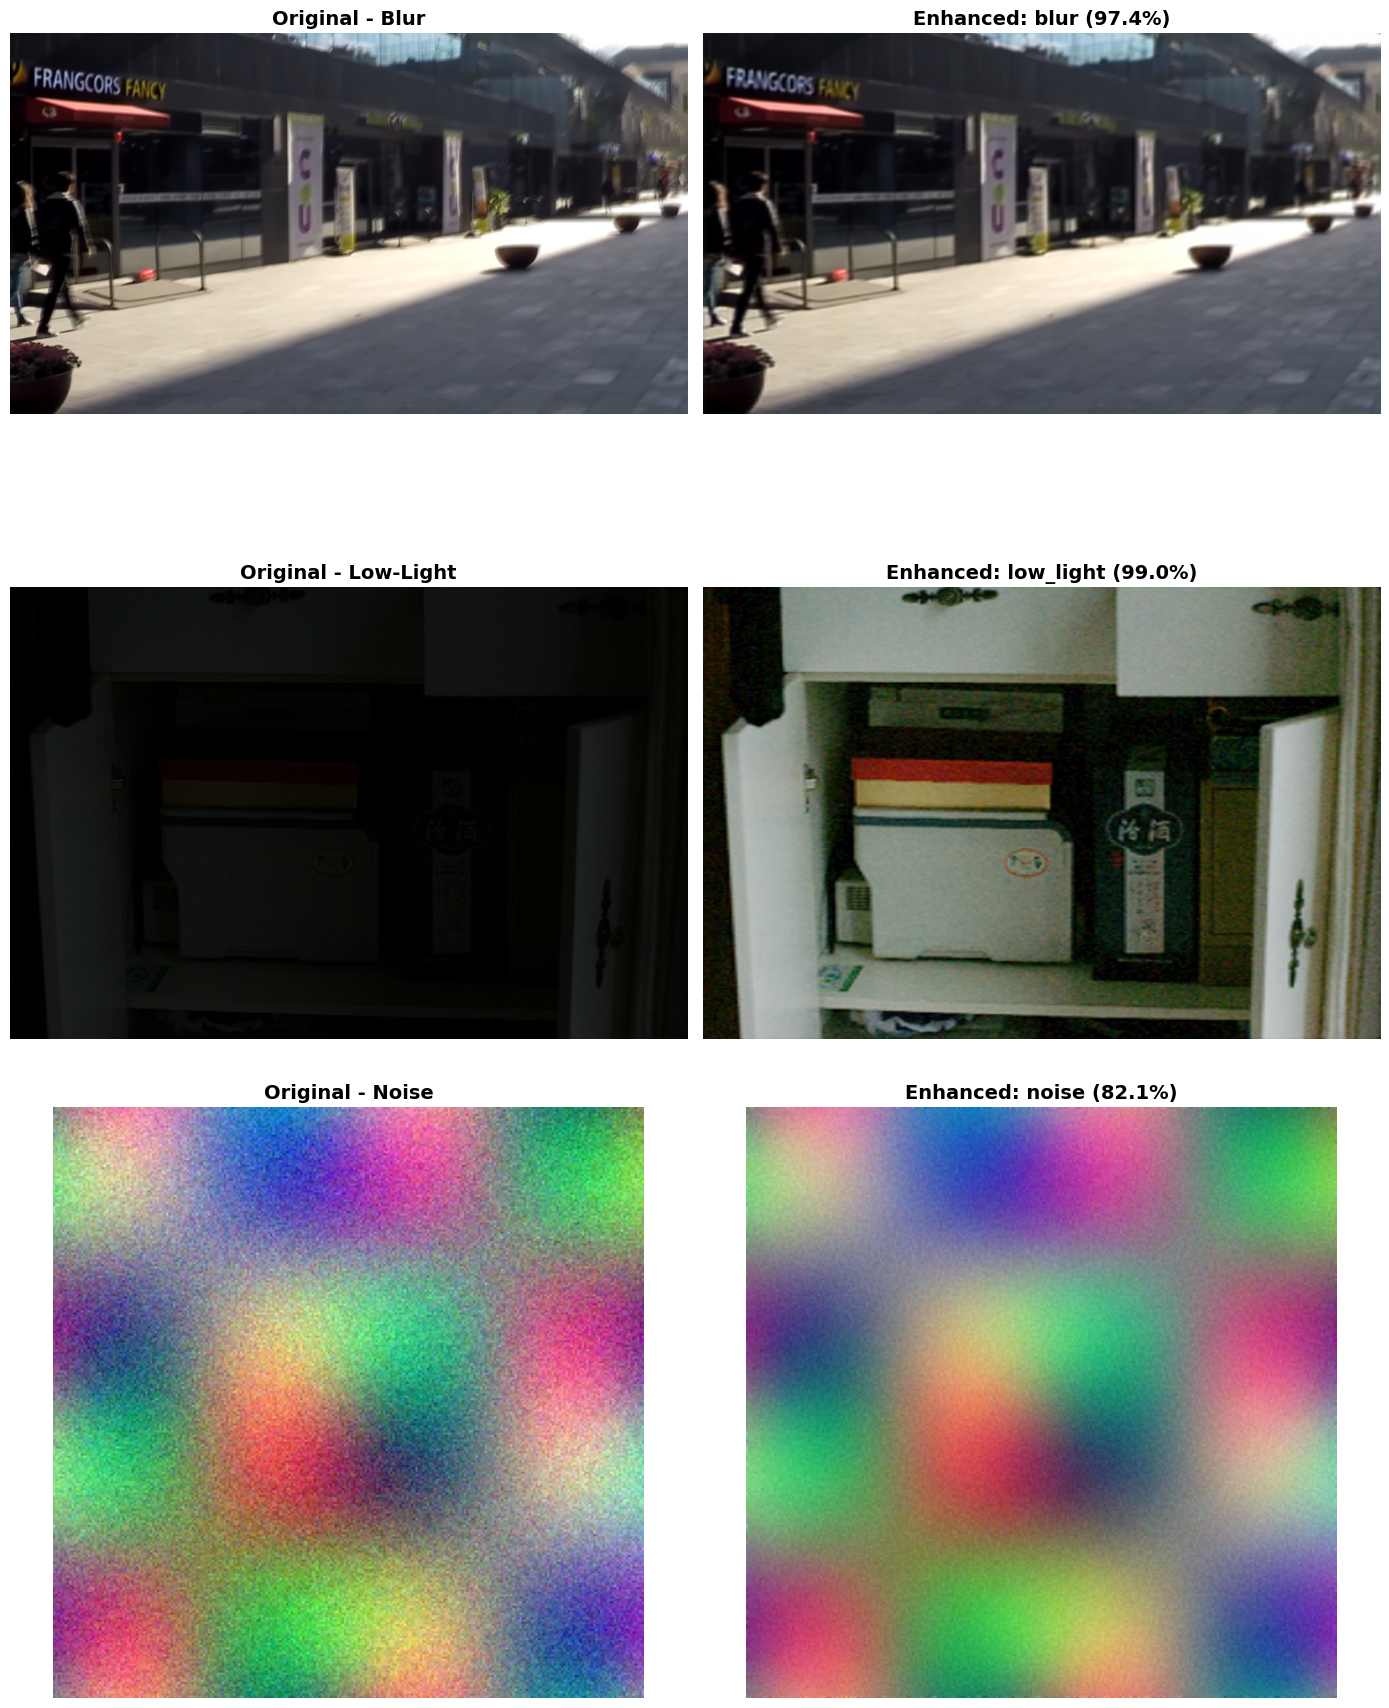

✓ Testing complete!


In [ ]:

import matplotlib.pyplot as plt
from pathlib import Path
def find_test_images():
    """Find available test images"""
    test_images = {}


    blur_path = Path('datasets/gopro_deblur/blur/images')
    if blur_path.exists():
        blur_imgs = list(blur_path.glob('*.png')) + list(blur_path.glob('*.jpg'))
        if blur_imgs:
            test_images['Blur'] = str(blur_imgs[0])


    lol_path = Path('datasets/LOL/eval15/low')
    if lol_path.exists():
        lol_imgs = list(lol_path.glob('*.png')) + list(lol_path.glob('*.jpg'))
        if lol_imgs:
            test_images['Low-Light'] = str(lol_imgs[0])


    noise_path = Path('datasets/synthetic_noise/test/noisy')
    if noise_path.exists():
        noise_imgs = list(noise_path.glob('*.jpg'))
        if noise_imgs:
            test_images['Noise'] = str(noise_imgs[0])

    return test_images


test_images = find_test_images()

if len(test_images) == 0:
    print("No test images found! Upload an image to test.")
else:
    print(f"Found {len(test_images)} test images:\n")

    # Create figure
    fig, axes = plt.subplots(len(test_images), 2, figsize=(14, 6*len(test_images)))

    if len(test_images) == 1:
        axes = axes.reshape(1, -1)

    # Test each image
    for idx, (degradation_name, img_path) in enumerate(test_images.items()):
        print(f"Testing {degradation_name}: {img_path}")

        # Enhance image
        result = restoration_system.enhance(img_path)

        # Display original
        axes[idx, 0].imshow(result['original_image'])
        axes[idx, 0].set_title(f'Original - {degradation_name}', fontsize=14, fontweight='bold')
        axes[idx, 0].axis('off')

        # Display enhanced
        axes[idx, 1].imshow(result['enhanced_image'])
        axes[idx, 1].set_title(f"Enhanced: {result['degradation_type']} ({result['confidence']:.1%})",
                               fontsize=14, fontweight='bold')
        axes[idx, 1].axis('off')

        print(f"  ✓ Detected: {result['degradation_type']}, Confidence: {result['confidence']:.1%}\n")

    plt.tight_layout()
    plt.show()

    print("✓ Testing complete!")

In [ ]:

image_path_to_fix = 'datasets/GoPro2/blur/000001.png'

save_location = 'models/restored_output/lol_enhanced_1.png'

import os
os.makedirs('models/restored_output', exist_ok=True)


result = restoration_system.enhance(
    image_path=image_path_to_fix,
    save_path=save_location
)

print(f"System detected: {result['degradation_type']} with confidence: {result['confidence']:.2f}")


System detected: blur with confidence: 0.95


In [ ]:


import numpy as np
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

def evaluate_quantitative_results():
    """Calculate PSNR, SSIM, and Classification metrics"""

    print("="*70)
    print("QUANTITATIVE EVALUATION")
    print("="*70)

    # Load models
    print("\nLoading models...")
    deblur_model = LightweightDeblurNet().to(device)
    denoise_model = LightweightDenoiseNet().to(device)
    lowlight_model = LightweightLowLightNet().to(device)
    classifier_model = DegradationClassifier().to(device)

    deblur_model.load_state_dict(torch.load('models/checkpoints/deblur_model.pth'))
    denoise_model.load_state_dict(torch.load('models/checkpoints/denoise_model.pth'))
    lowlight_model.load_state_dict(torch.load('models/checkpoints/lowlight_model.pth'))
    classifier_model.load_state_dict(torch.load('models/checkpoints/classifier_model.pth'))

    deblur_model.eval()
    denoise_model.eval()
    lowlight_model.eval()
    classifier_model.eval()

    results = {'deblur': [], 'denoise': [], 'lowlight': []}

    # Load test datasets
    print("\nLoading test datasets...")
    gopro_test = GoProDataset('datasets/gopro_deblur', 'test')
    gopro2_test = GoPro2Dataset('datasets/GoPro2', 'test')
    lol_test = LOLDataset('datasets/LOL', 'test')
    noise_test = SyntheticNoiseDataset('datasets/synthetic_noise', 'test')

    deblur_test = ConcatDataset([gopro_test, gopro2_test])

    datasets = {
        'deblur': (deblur_test, deblur_model),
        'lowlight': (lol_test, lowlight_model),
        'denoise': (noise_test, denoise_model)
    }

    # Evaluate each model
    for model_type, (dataset, model) in datasets.items():
        print(f"\nEvaluating {model_type}... ({len(dataset)} samples)")
        loader = DataLoader(dataset, batch_size=1, shuffle=False)

        psnr_values = []
        ssim_values = []

        for batch in tqdm(loader, desc=f"{model_type.upper()}"):
            degraded = batch['degraded'].to(device)
            clean = batch['clean'].to(device)

            with torch.no_grad():
                enhanced = model(degraded)

            # Convert to numpy [0,1]
            clean_np = clean.squeeze().cpu().numpy().transpose(1,2,0)
            enhanced_np = enhanced.squeeze().cpu().numpy().transpose(1,2,0)

            # Calculate metrics
            psnr_val = psnr(clean_np, enhanced_np, data_range=1.0)
            ssim_val = ssim(clean_np, enhanced_np, channel_axis=2, data_range=1.0)

            psnr_values.append(psnr_val)
            ssim_values.append(ssim_val)

        results[model_type] = {
            'psnr': psnr_values,
            'ssim': ssim_values,
            'avg_psnr': np.mean(psnr_values),
            'avg_ssim': np.mean(ssim_values),
            'std_psnr': np.std(psnr_values),
            'std_ssim': np.std(ssim_values)
        }

    # Evaluate classifier
    print("\nEvaluating classifier...")

    # Combine all test datasets
    all_test = ConcatDataset([deblur_test, lol_test, noise_test])
    test_loader = DataLoader(all_test, batch_size=16, shuffle=False)

    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Classification"):
            images = batch['degraded'].to(device)
            labels = batch['degradation_type'].to(device)

            logits = classifier_model(images)
            preds = torch.argmax(logits, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Print Results
    print("\n" + "="*70)
    print("RESTORATION RESULTS")
    print("="*70)

    print("\nTABLE I: PERFORMANCE ON BENCHMARK DATASETS\n")
    print(f"{'Method':<20} {'PSNR (dB)':<12} {'SSIM':<10}")
    print("-"*42)

    for model_type, metrics in results.items():
        print(f"{model_type.upper():<20} {metrics['avg_psnr']:<12.2f} {metrics['avg_ssim']:<10.4f}")

    print("\n" + "="*70)
    print("CLASSIFICATION RESULTS")
    print("="*70)

    print("\nTABLE II: DEGRADATION CLASSIFICATION\n")

    # Classification report
    target_names = ['Blur', 'Low-light', 'Noise']
    report = classification_report(y_true, y_pred, target_names=target_names,
                                   output_dict=True, zero_division=0)

    print(f"{'Type':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("-"*51)
    for name in target_names:
        if name.lower() in report:
            metrics = report[name.lower()]
            print(f"{name:<15} {metrics['precision']:<12.3f} {metrics['recall']:<12.3f} {metrics['f1-score']:<12.3f}")

    print(f"\n{'Overall Accuracy':<15} {report['accuracy']:.3f}")
    print(f"{'Weighted Avg':<15} {report['weighted avg']['precision']:<12.3f} "
          f"{report['weighted avg']['recall']:<12.3f} {report['weighted avg']['f1-score']:<12.3f}")

    # Confusion Matrix
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    # Save results to file
    with open('results/quantitative_results.txt', 'w') as f:
        f.write("QUANTITATIVE EVALUATION RESULTS\n")
        f.write("="*70 + "\n\n")

        f.write("RESTORATION METRICS:\n")
        for model_type, metrics in results.items():
            f.write(f"\n{model_type.upper()}:\n")
            f.write(f"  PSNR: {metrics['avg_psnr']:.2f} ± {metrics['std_psnr']:.2f} dB\n")
            f.write(f"  SSIM: {metrics['avg_ssim']:.4f} ± {metrics['std_ssim']:.4f}\n")

        f.write("\n" + "="*70 + "\n")
        f.write("CLASSIFICATION METRICS:\n")
        f.write(f"  Accuracy: {report['accuracy']:.3f}\n")
        f.write(f"  Precision: {report['weighted avg']['precision']:.3f}\n")
        f.write(f"  Recall: {report['weighted avg']['recall']:.3f}\n")
        f.write(f"  F1-Score: {report['weighted avg']['f1-score']:.3f}\n")

    print("\n✓ Results saved to: results/quantitative_results.txt")

    return results, report


# RUN EVALUATION
results, classification_report = evaluate_quantitative_results()

QUANTITATIVE EVALUATION

Loading models...

Loading test datasets...
   GoPro test: 206 samples
   GoPro2 test: 195 samples
   LOL test: 15 samples
   Synthetic Noise test: 200 samples

Evaluating deblur... (401 samples)


DEBLUR: 100%|██████████| 401/401 [03:39<00:00,  1.82it/s]



Evaluating lowlight... (15 samples)


LOWLIGHT: 100%|██████████| 15/15 [00:08<00:00,  1.68it/s]



Evaluating denoise... (200 samples)


DENOISE: 100%|██████████| 200/200 [01:27<00:00,  2.27it/s]



Evaluating classifier...


Classification: 100%|██████████| 39/39 [00:40<00:00,  1.03s/it]


RESTORATION RESULTS

TABLE I: PERFORMANCE ON BENCHMARK DATASETS

Method               PSNR (dB)    SSIM      
------------------------------------------
DEBLUR               30.39        0.9221    
DENOISE              31.22        0.7101    
LOWLIGHT             19.68        0.7492    

CLASSIFICATION RESULTS

TABLE II: DEGRADATION CLASSIFICATION

Type            Precision    Recall       F1-Score    
---------------------------------------------------

Overall Accuracy 1.000
Weighted Avg    1.000        1.000        1.000       

Confusion Matrix:
[[401   0   0]
 [  0  15   0]
 [  0   0 200]]

✓ Results saved to: results/quantitative_results.txt


In [ ]:
def continue_training_specific_models(additional_epochs=10):
    """Continue training ONLY blur and denoise models"""

    print("="*70)
    print("CONTINUING TRAINING - BLUR & DENOISE MODELS")
    print("="*70)

    # Load datasets
    gopro_train = GoProDataset('datasets/gopro_deblur', 'train')
    gopro_test = GoProDataset('datasets/gopro_deblur', 'test')
    gopro2_train = GoPro2Dataset('datasets/GoPro2', 'train')
    gopro2_test = GoPro2Dataset('datasets/GoPro2', 'test')
    noise_train = SyntheticNoiseDataset('datasets/synthetic_noise', 'train')
    noise_test = SyntheticNoiseDataset('datasets/synthetic_noise', 'test')

    deblur_train = ConcatDataset([gopro_train, gopro2_train])
    deblur_test = ConcatDataset([gopro_test, gopro2_test])

    # Load existing models
    deblur_model = LightweightDeblurNet().to(device)
    denoise_model = LightweightDenoiseNet().to(device)

    deblur_model.load_state_dict(torch.load('models/checkpoints/deblur_model.pth'))
    denoise_model.load_state_dict(torch.load('models/checkpoints/denoise_model.pth'))

    # Loss functions with HIGHER perceptual loss weight
    l1_loss = nn.L1Loss()
    perceptual_loss = PerceptualLoss().to(device)


    print("\n Retraining DEBLUR model...")

    deblur_loader_train = DataLoader(deblur_train, batch_size=16, shuffle=True,
                                     num_workers=2, pin_memory=True)
    deblur_loader_test = DataLoader(deblur_test, batch_size=8, shuffle=False,
                                    num_workers=2, pin_memory=True)

    optimizer = torch.optim.AdamW(deblur_model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=additional_epochs)
    scaler = torch.cuda.amp.GradScaler()

    best_loss = float('inf')

    for epoch in range(additional_epochs):
        deblur_model.train()
        train_loss = 0.0

        for batch in tqdm(deblur_loader_train, desc=f"Deblur Epoch {epoch+1}/{additional_epochs}"):
            degraded = batch['degraded'].to(device)
            clean = batch['clean'].to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                enhanced = deblur_model(degraded)
                loss_l1 = l1_loss(enhanced, clean)
                loss_perc = perceptual_loss(enhanced, clean)
                loss = loss_l1 + 0.5 * loss_perc  # INCREASED perceptual weight

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(deblur_loader_train)

        # Validation
        deblur_model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for batch in deblur_loader_test:
                degraded = batch['degraded'].to(device)
                clean = batch['clean'].to(device)

                enhanced = deblur_model(degraded)
                loss = l1_loss(enhanced, clean)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(deblur_loader_test)

        print(f"Epoch {epoch+1}: Train={avg_train_loss:.6f}, Val={avg_val_loss:.6f}")

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(deblur_model.state_dict(), 'models/checkpoints/deblur_model.pth')
            print(f"  ✓ Best deblur model saved! Loss: {best_loss:.6f}")

        scheduler.step()
        torch.cuda.empty_cache()

    print(f"\n Deblur retraining complete! Best loss: {best_loss:.6f}")


    print("\n Retraining DENOISE model...")

    denoise_loader_train = DataLoader(noise_train, batch_size=16, shuffle=True,
                                     num_workers=2, pin_memory=True)
    denoise_loader_test = DataLoader(noise_test, batch_size=8, shuffle=False,
                                    num_workers=2, pin_memory=True)

    optimizer = torch.optim.AdamW(denoise_model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=additional_epochs)
    scaler = torch.cuda.amp.GradScaler()

    best_loss = float('inf')

    for epoch in range(additional_epochs):
        denoise_model.train()
        train_loss = 0.0

        for batch in tqdm(denoise_loader_train, desc=f"Denoise Epoch {epoch+1}/{additional_epochs}"):
            degraded = batch['degraded'].to(device)
            clean = batch['clean'].to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                enhanced = denoise_model(degraded)
                loss_l1 = l1_loss(enhanced, clean)
                loss_perc = perceptual_loss(enhanced, clean)
                loss = loss_l1 + 0.5 * loss_perc  # INCREASED perceptual weight

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(denoise_loader_train)

        # Validation
        denoise_model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for batch in denoise_loader_test:
                degraded = batch['degraded'].to(device)
                clean = batch['clean'].to(device)

                enhanced = denoise_model(degraded)
                loss = l1_loss(enhanced, clean)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(denoise_loader_test)

        print(f"Epoch {epoch+1}: Train={avg_train_loss:.6f}, Val={avg_val_loss:.6f}")

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(denoise_model.state_dict(), 'models/checkpoints/denoise_model.pth')
            print(f"  ✓ Best denoise model saved! Loss: {best_loss:.6f}")

        scheduler.step()
        torch.cuda.empty_cache()

    print(f"\n Denoise retraining complete! Best loss: {best_loss:.6f}")

    print("\n" + "="*70)
    print("RETRAINING COMPLETE!")
    print("="*70)
    print("Reload the system:")
    print("  restoration_system = AdaptiveRestorationSystem()")

    return deblur_model, denoise_model



In [ ]:
continue_training_specific_models(additional_epochs=10)

CONTINUING TRAINING - BLUR & DENOISE MODELS
GoPro train: 823 samples
GoPro test: 206 samples
GoPro2 train: 780 samples
GoPro2 test: 195 samples
   Synthetic Noise train: 800 samples
   Synthetic Noise test: 200 samples


/tmp/ipython-input-4198247903.py:42: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()



🔄 Retraining DEBLUR model...


Deblur Epoch 1/10:   0%|          | 0/101 [00:00<?, ?it/s]/tmp/ipython-input-4198247903.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Deblur Epoch 1/10: 100%|██████████| 101/101 [14:01<00:00,  8.33s/it]


Epoch 1: Train=0.389495, Val=0.018957
  ✓ Best deblur model saved! Loss: 0.018957


...

Denoise Epoch 9/10: 100%|██████████| 50/50 [00:20<00:00,  2.48it/s]


Epoch 9: Train=0.192389, Val=0.022307
  ✓ Best denoise model saved! Loss: 0.022307


Denoise Epoch 10/10: 100%|██████████| 50/50 [00:20<00:00,  2.48it/s]


Epoch 10: Train=0.192452, Val=0.022296
  ✓ Best denoise model saved! Loss: 0.022296

✅ Denoise retraining complete! Best loss: 0.022296

RETRAINING COMPLETE!
Reload the system:
  restoration_system = AdaptiveRestorationSystem()


(LightweightDeblurNet(
   (enc1): Sequential(
     (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU(inplace=True)
     (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (3): ReLU(inplace=True)
   )
   (enc2): Sequential(
     (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU(inplace=True)
     (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (3): ReLU(inplace=True)
   )
   (enc3): Sequential(
     (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU(inplace=True)
     (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (3): ReLU(inplace=True)
   )
   (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   (bottleneck): Sequential(
     (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU(inplace=True)
     (2): Conv2d(256, 256, kernel_size=

In [ ]:
# Reload improved models
restoration_system = AdaptiveRestorationSystem()



✓ Adaptive Restoration System loaded


In [ ]:
import os
import torch
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader, ConcatDataset
import torch.nn as nn
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim



def evaluate_quantitative_results():
    """Calculate PSNR, SSIM, and Classification metrics"""

    print("="*70)
    print("QUANTITATIVE EVALUATION")
    print("="*70)

    # Load models
    print("\nLoading models...")
    deblur_model = LightweightDeblurNet().to(device)
    denoise_model = LightweightDenoiseNet().to(device)
    lowlight_model = LightweightLowLightNet().to(device)
    classifier_model = DegradationClassifier().to(device)

    deblur_model.load_state_dict(torch.load('models/checkpoints/deblur_model.pth'))
    denoise_model.load_state_dict(torch.load('models/checkpoints/denoise_model.pth'))
    lowlight_model.load_state_dict(torch.load('models/checkpoints/lowlight_model.pth'))
    classifier_model.load_state_dict(torch.load('models/checkpoints/classifier_model.pth'))

    deblur_model.eval()
    denoise_model.eval()
    lowlight_model.eval()
    classifier_model.eval()

    results = {'deblur': [], 'denoise': [], 'lowlight': []}


    print("\nLoading test datasets...")
    gopro_test = GoProDataset('datasets/gopro_deblur', 'test')
    gopro2_test = GoPro2Dataset('datasets/GoPro2', 'test')
    lol_test = LOLDataset('datasets/LOL', 'test')
    noise_test = SyntheticNoiseDataset('datasets/synthetic_noise', 'test')

    print(f"   GoPro test: {len(gopro_test)} samples")
    print(f"   GoPro2 test: {len(gopro2_test)} samples")
    print(f"   LOL test: {len(lol_test)} samples")
    print(f"   Synthetic Noise test: {len(noise_test)} samples")

    deblur_test = ConcatDataset([gopro_test, gopro2_test])

    datasets = {
        'deblur': (deblur_test, deblur_model),
        'lowlight': (lol_test, lowlight_model),
        'denoise': (noise_test, denoise_model)
    }


    for model_type, (dataset, model) in datasets.items():
        print(f"\nEvaluating {model_type}... ({len(dataset)} samples)")
        loader = DataLoader(dataset, batch_size=1, shuffle=False)

        psnr_values = []
        ssim_values = []

        for batch in tqdm(loader, desc=f"{model_type.upper()}"):
            degraded = batch['degraded'].to(device)
            clean = batch['clean'].to(device)

            with torch.no_grad():
                enhanced = model(degraded)

            clean_np = clean.squeeze().cpu().numpy().transpose(1, 2, 0)
            enhanced_np = enhanced.squeeze().cpu().numpy().transpose(1, 2, 0)

            psnr_val = psnr(clean_np, enhanced_np, data_range=1.0)
            ssim_val = ssim(clean_np, enhanced_np, channel_axis=2, data_range=1.0)

            psnr_values.append(psnr_val)
            ssim_values.append(ssim_val)

        results[model_type] = {
            'psnr': psnr_values,
            'ssim': ssim_values,
            'avg_psnr': np.mean(psnr_values),
            'avg_ssim': np.mean(ssim_values),
            'std_psnr': np.std(psnr_values),
            'std_ssim': np.std(ssim_values)
        }

    print("\nEvaluating classifier...")

    y_true = []
    y_pred = []

    test_datasets = [
        (gopro_test, 0),
        (gopro2_test, 0),
        (lol_test, 1),
        (noise_test, 2)
    ]

    for dataset, true_label in test_datasets:
        loader = DataLoader(dataset, batch_size=16, shuffle=False)

        with torch.no_grad():
            for batch in loader:
                images = batch['degraded'].to(device)

                logits = classifier_model(images)
                preds = torch.argmax(logits, dim=1)

                batch_size = images.size(0)
                y_true.extend([true_label] * batch_size)
                y_pred.extend(preds.cpu().numpy())

    print("\n" + "="*70)
    print("RESTORATION RESULTS")
    print("="*70)

    print("\nTABLE I: PERFORMANCE ON BENCHMARK DATASETS\n")
    print(f"{'Method':<20} {'PSNR (dB)':<12} {'SSIM':<10}")
    print("-"*42)

    for model_type, metrics in results.items():
        print(f"{model_type.upper():<20} {metrics['avg_psnr']:<12.2f} {metrics['avg_ssim']:<10.4f}")

    print("\n" + "="*70)
    print("CLASSIFICATION RESULTS")
    print("="*70)

    print("\nTABLE II: DEGRADATION CLASSIFICATION\n")

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1, 2], zero_division=0
    )
    accuracy = accuracy_score(y_true, y_pred)

    target_names = ['Blur', 'Low-light', 'Noise']

    print(f"{'Type':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("-"*51)

    for idx, name in enumerate(target_names):
        print(f"{name:<15} {precision[idx]:<12.3f} {recall[idx]:<12.3f} {f1[idx]:<12.3f}")

    print(f"\n{'Overall Accuracy':<15} {accuracy:.3f}")

    weighted_precision = np.average(precision, weights=support)
    weighted_recall = np.average(recall, weights=support)
    weighted_f1 = np.average(f1, weights=support)

    print(f"{'Weighted Avg':<15} {weighted_precision:<12.3f} "
          f"{weighted_recall:<12.3f} {weighted_f1:<12.3f}")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    print(cm)

    # Save results
    os.makedirs('results', exist_ok=True)
    with open('results/quantitative_results.txt', 'w') as f:
        f.write("QUANTITATIVE EVALUATION RESULTS\n")
        f.write("="*70 + "\n\n")

        f.write("RESTORATION METRICS:\n")
        for model_type, metrics in results.items():
            f.write(f"\n{model_type.upper()}:\n")
            f.write(f"  PSNR: {metrics['avg_psnr']:.2f} ± {metrics['std_psnr']:.2f} dB\n")
            f.write(f"  SSIM: {metrics['avg_ssim']:.4f} ± {metrics['std_ssim']:.4f}\n")

        f.write("\n" + "="*70 + "\n")
        f.write("CLASSIFICATION METRICS:\n")
        f.write(f"  Accuracy: {accuracy:.3f}\n")
        f.write(f"  Precision: {weighted_precision:.3f}\n")
        f.write(f"  Recall: {weighted_recall:.3f}\n")
        f.write(f"  F1-Score: {weighted_f1:.3f}\n")

    print("\n✓ Results saved to: results/quantitative_results.txt")

    return results, {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}


results, report = evaluate_quantitative_results()


QUANTITATIVE EVALUATION

Loading models...

Loading test datasets...
   GoPro test: 206 samples
   GoPro2 test: 195 samples
   LOL test: 115 samples
   Synthetic Noise test: 200 samples
   GoPro test: 206 samples
   GoPro2 test: 195 samples
   LOL test: 115 samples
   Synthetic Noise test: 200 samples

Evaluating deblur... (401 samples)


DEBLUR: 100%|██████████| 401/401 [06:00<00:00,  1.11it/s]



Evaluating lowlight... (115 samples)


LOWLIGHT: 100%|██████████| 115/115 [01:14<00:00,  1.55it/s]



Evaluating denoise... (200 samples)


DENOISE: 100%|██████████| 200/200 [02:50<00:00,  1.17it/s]



Evaluating classifier...

RESTORATION RESULTS

TABLE I: PERFORMANCE ON BENCHMARK DATASETS

Method               PSNR (dB)    SSIM      
------------------------------------------
DEBLUR               30.68        0.9233    
DENOISE              31.10        0.7088    
LOWLIGHT             17.17        0.7066    

CLASSIFICATION RESULTS

TABLE II: DEGRADATION CLASSIFICATION

Type            Precision    Recall       F1-Score    
---------------------------------------------------
Blur            1.000        1.000        1.000       
Low-light       1.000        1.000        1.000       
Noise           1.000        1.000        1.000       

Overall Accuracy 1.000
Weighted Avg    1.000        1.000        1.000       

Confusion Matrix:
[[401   0   0]
 [  0 115   0]
 [  0   0 200]]

✓ Results saved to: results/quantitative_results.txt


In [ ]:
!pip install gradio torch torchvision pillow


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from PIL import Image
import gradio as gr


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class LightweightDeblurNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = self._conv_block(3, 32)
        self.enc2 = self._conv_block(32, 64)
        self.enc3 = self._conv_block(64, 128)
        self.pool = nn.MaxPool2d(2, 2)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, 3, 1, 1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, 1, 1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, 3, 1, 1), nn.ReLU(inplace=True)
        )
        self.up3 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec3 = self._conv_block(192, 64)
        self.up2 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec2 = self._conv_block(96, 32)
        self.up1 = nn.ConvTranspose2d(32, 16, 2, 2)
        self.dec1 = self._conv_block(48, 16)
        self.final = nn.Conv2d(16, 3, 1)

    def _conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, 1, 1), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1), nn.ReLU(inplace=True)
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        return torch.clamp(self.final(d1), 0, 1)


class LightweightDenoiseNet(nn.Module):
    def __init__(self, num_layers=10):
        super().__init__()
        layers = [nn.Conv2d(3, 64, 3, 1, 1), nn.ReLU(inplace=True)]
        for _ in range(num_layers - 2):
            layers.extend([nn.Conv2d(64, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True)])
        layers.append(nn.Conv2d(64, 3, 3, 1, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return torch.clamp(x - self.network(x), 0, 1)


class LightweightLowLightNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ReLU(inplace=True)
        )
        self.curve_estimator = nn.Sequential(
            nn.Conv2d(64, 32, 3, 1, 1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 24, 3, 1, 1)
        )

    def forward(self, x):
        f = self.encoder(x)
        c = self.curve_estimator(f)
        enhanced = x
        for i in range(8):
            curve = torch.tanh(c[:, i*3:(i+1)*3, :, :]) * 0.4
            enhanced = enhanced + enhanced * (1 - enhanced) * curve
        return torch.clamp(enhanced, 0, 1)


class DegradationClassifier(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, 2, 1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, 2, 1), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = F.interpolate(x, (128, 128), mode='bilinear', align_corners=False)
        return self.classifier(self.features(x))


class AdaptiveRestorationSystem:
    def __init__(self):
        self.device = device
        self.deblur = LightweightDeblurNet().to(device)
        self.denoise = LightweightDenoiseNet().to(device)
        self.lowlight = LightweightLowLightNet().to(device)
        self.classifier = DegradationClassifier(num_classes=4).to(device)

        base = "/content/drive/MyDrive/AdaptiveImageRestoration/models/checkpoints"

        self.deblur.load_state_dict(torch.load(f"{base}/deblur_model.pth", map_location=device))
        self.denoise.load_state_dict(torch.load(f"{base}/denoise_model.pth", map_location=device))
        self.lowlight.load_state_dict(torch.load(f"{base}/lowlight_model.pth", map_location=device))

        state_dict = torch.load(f"{base}/classifier_model.pth", map_location=device)
        new_state_dict = {}
        for k, v in state_dict.items():
            if "classifier.5" in k:
                new_k = k.replace("classifier.5", "classifier.4")
            else:
                new_k = k
            new_state_dict[new_k] = v
        self.classifier.load_state_dict(new_state_dict, strict=False)

        for m in [self.deblur, self.denoise, self.lowlight, self.classifier]:
            m.eval()

        self.names = ['blur', 'low_light', 'noise', 'clean']

    def preprocess(self, img):
        img = img.convert('RGB')
        original_size = img.size
        img = img.resize((256, 256))
        t = torch.tensor(np.array(img)).permute(2, 0, 1).float() / 255.0
        return t.unsqueeze(0).to(device), original_size

    def postprocess(self, t, size):
        t = t.squeeze(0).cpu().clamp(0, 1)
        img = Image.fromarray((t.permute(1, 2, 0).numpy() * 255).astype(np.uint8))
        return img.resize(size)

    def enhance(self, image):
        img_tensor, size = self.preprocess(image)
        with torch.no_grad():
            pred = torch.argmax(F.softmax(self.classifier(img_tensor), dim=1)).item()
            degradation = self.names[pred]
            if degradation == 'blur':
                output = self.deblur(img_tensor)
            elif degradation == 'noise':
                output = self.denoise(img_tensor)
            elif degradation == 'low_light':
                output = self.lowlight(img_tensor)
            else:
                output = img_tensor
        restored = self.postprocess(output, size)
        return restored, degradation


system = AdaptiveRestorationSystem()


def process_image(image):
    restored, degradation = system.enhance(image)
    return restored, f"Detected degradation: {degradation}"

demo = gr.Interface(
    fn=process_image,
    inputs=gr.Image(type="pil", label="Upload Degraded Image"),
    outputs=[gr.Image(label="Restored Image"), gr.Textbox(label="Degradation Type")],
    title="🖼️ Adaptive Image Restoration System",
    description="Automatically detects and restores images degraded by blur, noise, or low light."
)

demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c42434f7c9be56657a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
